# CNN for images

In [1]:
import numpy as np
import pandas as pd

### Load split data

In [2]:
train_df = pd.read_csv(
    "data/train_df.csv",
    parse_dates=["publish_timestamp"]  # converts datestime string into datetime object
)
test_df = pd.read_csv(
    "data/test_df.csv",
    parse_dates=["publish_timestamp"]
)

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77574 entries, 0 to 77573
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   77574 non-null  int64         
 1   username                  77574 non-null  object        
 2   publish_timestamp         77574 non-null  datetime64[ns]
 3   has_location              77574 non-null  int64         
 4   is_carousel               77574 non-null  int64         
 5   num_images                77574 non-null  int64         
 6   is_sponsored              77574 non-null  int64         
 7   image_path                77574 non-null  object        
 8   caption                   77574 non-null  object        
 9   following                 77574 non-null  int64         
 10  follower_following_ratio  77574 non-null  float64       
 11  hour                      77574 non-null  int64         
 12  day               

In [4]:
y_train = train_df["engagement_label"].values

y_test = test_df["engagement_label"].values

# Set random seed

In [5]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    # Ensure deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

### Obtain images

In [6]:
train_df['image_path'].value_counts()

image_path
['E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image\\erikamariemua-1152933090499334773.jpg']                                                                                                                                                                                                                                                            1
['E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image\\sheltiesandwich-1863712094270431077.jpg']                                                                                                                                                                                                                                                          1
['E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image\\sheltiesandwich-1859348266527216542.jpg']                                                                                                  

In [7]:
# # Multiple images in image_path, to each be mapped to the engagement label
# train_df = train_df.explode("image_path").reset_index(drop=True)
# test_df = test_df.explode("image_path").reset_index(drop=True)

### Show an example image

In [8]:
import ast

train_df["image_path"] = train_df["image_path"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Multiple images in image_path, to each be mapped to the engagement label
train_df = train_df.explode("image_path").reset_index(drop=True)

In [9]:
# from pathlib import Path

# base_dir = Path("E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image")

# train_df["image_path"] = train_df["image_path"].apply(
#     lambda paths: [str(base_dir / Path(p).name) for p in paths]
# )

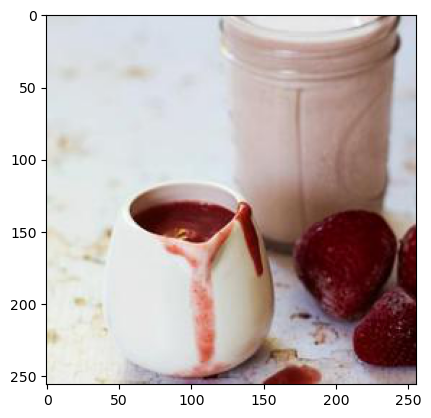

In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

# show_image(np.random.choice(train_df['image_path'].unique()))
show_image(np.random.choice(train_df["image_path"]))
# show_image('E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image/thegreenhub-1805832255635869031.jpg')

### Convert and explode test images too

In [11]:
import ast

test_df["image_path"] = test_df["image_path"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Multiple images in image_path, to each be mapped to the engagement label
test_df = test_df.explode("image_path").reset_index(drop=True)

### Filter invalid paths before training

In [ ]:
from pathlib import Path

# Path to your images folder
base_dir = Path("E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image")

# Build a set of all image filenames
all_files = set(str(p) for p in base_dir.glob("*.*"))  # or "*.jpg" if only jpg

# Keep only rows that exist
train_df = train_df[train_df["image_path"].isin(all_files)].reset_index(drop=True)


In [ ]:
from pathlib import Path

# Path to your images folder
base_dir = Path("E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image")

# Build a set of all image filenames
all_files = set(str(p) for p in base_dir.glob("*.*"))  # or "*.jpg" if only jpg

# Keep only rows that exist
test_df = test_df[test_df["image_path"].isin(all_files)].reset_index(drop=True)


In [ ]:
# import os

# train_df = train_df[train_df["image_path"].apply(os.path.exists)].reset_index(drop=True)
# test_df  = test_df[test_df["image_path"].apply(os.path.exists)].reset_index(drop=True)


In [ ]:
print(len(train_df))
print(len(test_df))

### Define image transforms

In [61]:
from torchvision import transforms

IMAGE_SIZE = 224  # ResNet expects 224x224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),   # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],        # ImageNet mean
        std=[0.229, 0.224, 0.225]          # ImageNet std
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


### Create Image Dataset class

In [62]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

class ImageDataset(Dataset):
    def __init__(self, df, img_col="image_path", target_col="engagement_label", transform=None):
        self.df = df.reset_index(drop=True)
        self.img_col = img_col
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # print("Loading image:", self.df.iloc[idx]['image_path'])
        img_path = self.df.loc[idx, self.img_col]
        label = self.df.loc[idx, self.target_col]

        # Load image
        img = Image.open(img_path).convert("RGB")  # make sure it's RGB
        
        if self.transform:
            img = self.transform(img)
        
        return img, label


In [63]:
train_ds = ImageDataset(train_df, transform=train_transform)
test_ds  = ImageDataset(test_df, transform=test_transform)

### DataLoader

In [64]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

In [65]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True, # only for training
    num_workers=0,
    generator=g
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)


In [66]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([0.9816, 0.9949, 1.0245], device='cuda:0')


In [68]:
import torch.nn as nn 

device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss(weight=class_weights)


### Pretrained ResNet18 for images

In [69]:
import torch.nn as nn 
import torchvision.models as models
import torch.nn.functional as F

resnet = models.resnet18(weights="IMAGENET1K_V1")

class ImageResNet(nn.Module):
    def __init__(self, resnet_model, num_classes=3, dropout=0.5):
        super().__init__()
        self.resnet = resnet_model
        
        # Replace the final fc layer (classifier head)
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        return self.resnet(x)

# Set model
model = ImageResNet(resnet, num_classes=3).to(device)
# Freeze backbone
for name, param in model.resnet.named_parameters():
    if "fc" not in name:   # do not freeze fc
        param.requires_grad = False

# New fc layers are trainable by default
for param in model.resnet.fc.parameters():
    param.requires_grad = True

# Set optimizer
optimizer = torch.optim.Adam(
    model.resnet.fc.parameters(), # only train classifier head when frozen
    lr=1e-3
)


In [70]:
print(model)

ImageResNet(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

### Train and test loop

In [71]:

# training loop
def train_epoch(loader):
    print("Training")
    # Put model in training mode
    model.train()

    # Initialize accumulator for total loss
    total_loss = 0

    # Loops over batches in training set
    for batch in loader:
        # Detect if batch is a dict (BERT-style) or tuple (LSTM/MLP/CNN)
        if isinstance(batch, dict):
            # BERT-style
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # total_loss += loss.item()
            # correct += (logits.argmax(dim=1) == labels).sum().item()
            # total += labels.size(0)

        else:
            # Tuple-style: (X, y) for LSTM, MLP, CNN
            X, y = batch

            # Move x y to same device
            X, y = X.to(device), y.to(device)

            # Clear old gradients from previous batch
            optimizer.zero_grad()

            # Feeds batch into model, perform forward pass, output logits
            logits = model(X)
            # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            # Compute loss for this batch
            loss = criterion(logits, y)

            # Performs backpropagation: computes gradients of the loss with respect to each model parameter.
            loss.backward()

            # Updates model parameters using those gradients
            optimizer.step()

        # Adds the numeric loss value (converted from a tensor with .item()) to the total loss accumulator.
        total_loss += loss.item()

    # Average loss = total loss / number of batches
    avg_loss = total_loss / len(loader)
    
    return avg_loss




In [72]:
def test_epoch(loader):
    # Set model to evaluation mode. Disables dropout, freezes batchnorm stats
    model.eval()

    # Initialize accumulator for total loss
    total_loss = 0

    with torch.no_grad(): # Disables gradient tracking inside this block.
    # This saves memory and time, since we don’t need gradients for validation.
    # It also ensures the model’s weights won’t accidentally be updated.
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
                # total_loss += criterion(logits, labels).item()
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            total_loss += criterion(logits, y).item()

    # Compute average loss
    avg_loss = total_loss / len(loader)
    
    return avg_loss

In [73]:
from sklearn.metrics import confusion_matrix, f1_score

def evaluate_metrics(loader, model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)

                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Accuracy
    correct = sum(p == y for p, y in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return accuracy, cm, macro_f1


### Baseline

In [74]:
results = []
best_row = None

for epoch in range(10):
    train_loss = train_epoch(train_loader)
    test_loss  = test_epoch(test_loader)

    # Metrics
    train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

    best_row = {
        "model": "Baseline ResNet18",
        "best_epoch": epoch + 1,
        "train_macro_f1": train_macro_f1,
        "train_acc": train_acc,
        "train_cm": train_cm,
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
        "test_cm": test_cm,
    }
    results.append(best_row)

    print(f"\nEpoch {epoch+1}")
    print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

    print("Train Confusion Matrix:")
    print(train_cm)

    print("Test Confusion Matrix:")
    print(test_cm)

df_baseline = pd.DataFrame(results)


Training


FileNotFoundError: [Errno 2] No such file or directory: 'E:/instagram_dataset_raws/Instagram influencer dataset/Post_images/posts_image/image\\thegreenhub_-1805832255635869031.jpg'

In [ ]:
# Best model by test macro F1
best_row = df_baseline.loc[df_baseline["test_macro_f1"].idxmax()]
print(best_row)

model                                                 Baseline BERT
best_epoch                                                        4
train_macro_f1                                             0.537571
train_acc                                                  0.540449
train_cm          [[321, 105, 36], [158, 262, 76], [131, 170, 212]]
test_macro_f1                                              0.515168
test_acc                                                   0.526596
test_cm                  [[95, 40, 12], [41, 60, 13], [34, 38, 43]]
Name: 3, dtype: object


In [ ]:
# Rank models by test macro F1
df_baseline.sort_values("test_macro_f1", ascending=False).head(5)

,model,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm
3,Baseline BERT,4,0.537571,0.540449,"[[321, 105, 36], [158, 262, 76], [131, 170, 212]]",0.515168,0.526596,"[[95, 40, 12], [41, 60, 13], [34, 38, 43]]"
0,Baseline BERT,1,0.507328,0.507138,"[[272, 139, 51], [141, 266, 89], [101, 204, 208]]",0.505058,0.507979,"[[81, 50, 16], [36, 62, 16], [27, 40, 48]]"
9,Baseline BERT,10,0.540622,0.560843,"[[322, 36, 104], [150, 139, 207], [98, 51, 364]]",0.494089,0.518617,"[[93, 20, 34], [38, 30, 46], [29, 14, 72]]"
6,Baseline BERT,7,0.551179,0.560163,"[[265, 77, 120], [112, 188, 196], [63, 79, 371]]",0.493909,0.500000,"[[73, 30, 44], [31, 44, 39], [22, 22, 71]]"
5,Baseline BERT,6,0.528909,0.541808,"[[205, 92, 165], [69, 190, 237], [38, 73, 402]]",0.493714,0.500000,"[[60, 31, 56], [19, 46, 49], [14, 19, 82]]"


# Performance Tuning

### Reinitialize dataset, dataloader, device, criterion

In [ ]:
train_ds = ImageDataset(train_df, transform=train_transform)
test_ds  = ImageDataset(test_df, transform=test_transform)

In [ ]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)


In [ ]:
batch_size = 32

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True, # only for training
    num_workers=0,
    generator=g
)

test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [ ]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([1.0613, 0.9886, 0.9558], device='cuda:0')


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
criterion = nn.CrossEntropyLoss(weight=class_weights)


### Tuning loop

In [ ]:
import copy
import matplotlib.pyplot as plt

results = []
best_state = None
global_best_f1 = 0

patience = 5 # stop if no improvement after 5 epochs

# Initialize plot
plt.figure(figsize=(8,5))

for dropout in [0.3, 0.5]:
    for freeze_resnet in [True, False]:
        if freeze_resnet:
            lr_backbone = None
            lr_head = 1e-3
        else:
            lr_backbone = 1e-4
            lr_head = 1e-3


        print("\n=====\nNew tuning parameters: ")
        print(f"freeze_resnet: {freeze_resnet}")
        print(f"dropout: {dropout}")
        print(f"lr_backbone: {lr_backbone}")
        print(f"lr_head: {lr_head}\n")

        # Set parameters for model and optimizer
        resnet = models.resnet18(weights="IMAGENET1K_V1")
        model = ImageResNet(resnet, dropout=dropout).to(device)

        if freeze_resnet: # prevents ResNet weights from being updated
            # Freeze backbone
            for name, param in model.resnet.named_parameters():
                if "fc" not in name:   # do not freeze fc
                    param.requires_grad = False

            # New fc layers are trainable by default
            for param in model.resnet.fc.parameters():
                param.requires_grad = True

            # Optimizer
            optimizer = torch.optim.Adam(
                model.resnet.fc.parameters(),  # only train classifier head
                lr=lr_head
            )

        else:
            for param in model.resnet.parameters(): # freeze everything first
                param.requires_grad = False 
            for param in model.resnet.layer4.parameters(): # Unfreeze last layer4 block
                param.requires_grad = True
            for param in model.resnet.fc.parameters(): # Keep fc head trainable
                param.requires_grad = True

            # Set optimizer from partially unfrozen ResNet
            optimizer = torch.optim.Adam([
                {"params": model.resnet.layer4.parameters(), "lr": lr_backbone},
                {"params": model.resnet.fc.parameters(), "lr": lr_head},
            ])

        # for name, param in model.named_parameters():
        #     print(name, param.requires_grad)
        print(model)

        # Re-initialize metrics before epochs
        best_test_f1 = 0
        best_row = None
        no_improve_epochs = 0
        train_macro_f1_list = []
        test_macro_f1_list = []

        for epoch in range(50):
            train_loss = train_epoch(train_loader)
            test_loss  = test_epoch(test_loader)

            # Metrics
            # if (epoch + 1) % 10 == 0 or epoch == 0: # evaluate training model only every 10 epochs to save processing time
            train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
            # else:
            #     train_acc = train_macro_f1 = None
            #     train_cm = None
            test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

            # Keep metrics for plotting
            if train_macro_f1 is not None:
                train_macro_f1_list.append(train_macro_f1)
            else:
                train_macro_f1_list.append(train_macro_f1_list[-1] if train_macro_f1_list else None)
            test_macro_f1_list.append(test_macro_f1)

            if test_macro_f1 > best_test_f1:
                # Update best F1
                best_test_f1 = test_macro_f1
                # Save model metrics and parameters for plot/chart
                best_row = {
                    "model": "ResNet18",
                    "freeze_resnet": freeze_resnet,
                    "dropout": dropout,
                    "lr_backbone": lr_backbone,
                    "lr_head": lr_head,
                    "best_epoch": epoch + 1,
                    "train_macro_f1": train_macro_f1,
                    "train_acc": train_acc,
                    "train_cm": train_cm,
                    "test_macro_f1": test_macro_f1,
                    "test_acc": test_acc,
                    "test_cm": test_cm,

                    "train_f1_history": train_macro_f1_list.copy(),
                    "test_f1_history": test_macro_f1_list.copy(),
                }
                no_improve_epochs = 0  # reset patience counter
                if test_macro_f1 > global_best_f1:
                    # Update global best F1
                    global_best_f1 = test_macro_f1
                    # Save model state for loading later using load_state_dict
                    best_state = copy.deepcopy(model.state_dict())
            else:
                no_improve_epochs += 1

            

            print(f"\nEpoch {epoch+1}")
            if train_macro_f1 is not None:
                print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
            print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")
            if train_cm is not None:
                print("Train Confusion Matrix:")
                print(train_cm)

            print("Test Confusion Matrix:")
            print(test_cm)

            if no_improve_epochs >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
                    
        # Keep only the best epoch of the parameter configuration
        results.append(best_row)
            
df_results = pd.DataFrame(results)
torch.save(best_state, "best_resnet_model.pt")



=====
New tuning parameters: 
freeze_resnet: True
dropout: 0.3
lr_backbone: None
lr_head: 0.001

ImageResNet(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), paddi

<Figure size 800x500 with 0 Axes>

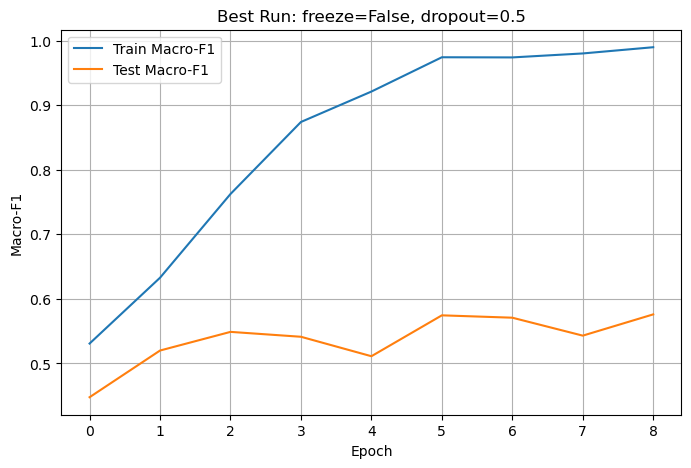

In [ ]:
best_run = max(results, key=lambda x: x["test_macro_f1"])

plt.figure(figsize=(8,5))
plt.plot(best_run["train_f1_history"], label="Train Macro-F1")
plt.plot(best_run["test_f1_history"], label="Test Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title(
    f"Best Run: freeze={best_run['freeze_resnet']}, "
    f"dropout={best_run['dropout']}"
)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Best model by test macro F1
best_row = df_results.loc[df_results["test_macro_f1"].idxmax()]
print(best_row)

model                                                        ResNet18
freeze_resnet                                                   False
dropout                                                           0.5
lr_backbone                                                    0.0001
lr_head                                                         0.001
best_epoch                                                          9
train_macro_f1                                               0.989749
train_acc                                                    0.989803
train_cm                      [[460, 1, 1], [7, 487, 2], [1, 3, 509]]
test_macro_f1                                                0.576036
test_acc                                                     0.579787
test_cm                    [[87, 34, 26], [28, 57, 29], [16, 25, 74]]
train_f1_history    [0.530888893986318, 0.6328044472322185, 0.7624...
test_f1_history     [0.4477532749754089, 0.5200656299403535, 0.548...
Name: 3, dtype: obje

In [ ]:
# Rank models by test macro F1
df_results.sort_values("test_macro_f1", ascending=False).head(5)

,model,freeze_resnet,dropout,lr_backbone,lr_head,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
3,ResNet18,False,0.5,0.0001,0.001,9,0.989749,0.989803,"[[460, 1, 1], [7, 487, 2], [1, 3, 509]]",0.576036,0.579787,"[[87, 34, 26], [28, 57, 29], [16, 25, 74]]","[0.530888893986318, 0.6328044472322185, 0.7624...","[0.4477532749754089, 0.5200656299403535, 0.548..."
1,ResNet18,False,0.3,0.0001,0.001,2,0.756985,0.758668,"[[388, 51, 23], [89, 323, 84], [51, 57, 405]]",0.564295,0.569149,"[[90, 36, 21], [35, 53, 26], [24, 20, 71]]","[0.6228577568883275, 0.7569846383959574]","[0.5558435881333097, 0.5642954970213001]"
2,ResNet18,True,0.5,NaN,0.001,11,0.592194,0.594154,"[[298, 88, 76], [121, 244, 131], [81, 100, 332]]",0.561702,0.563830,"[[85, 34, 28], [26, 63, 25], [30, 21, 64]]","[0.4957160880805272, 0.5100597739910816, 0.510...","[0.49023191415714784, 0.5012245140385504, 0.47..."
0,ResNet18,True,0.3,NaN,0.001,6,0.594672,0.593474,"[[254, 136, 72], [76, 316, 104], [53, 157, 303]]",0.530733,0.531915,"[[75, 45, 27], [23, 69, 22], [19, 40, 56]]","[0.46882453999895884, 0.47125374675119974, 0.5...","[0.46143297883385986, 0.44022079420003296, 0.4..."


In [ ]:
# Compare freeze_resnet effects
df_results.groupby("freeze_resnet")["test_macro_f1"].mean()

freeze_resnet
False    0.570166
True     0.546217
Name: test_macro_f1, dtype: float64

In [ ]:
# Compare dropout effects
df_results.groupby("dropout")["test_macro_f1"].mean()


dropout
0.3    0.547514
0.5    0.568869
Name: test_macro_f1, dtype: float64

In [ ]:
# Best epoch per configuration
df_results.loc[
    df_results.groupby(
        ["freeze_resnet", "dropout"]
    )["test_macro_f1"].idxmax()
]

,model,freeze_resnet,dropout,lr_backbone,lr_head,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
1,ResNet18,False,0.3,0.0001,0.001,2,0.756985,0.758668,"[[388, 51, 23], [89, 323, 84], [51, 57, 405]]",0.564295,0.569149,"[[90, 36, 21], [35, 53, 26], [24, 20, 71]]","[0.6228577568883275, 0.7569846383959574]","[0.5558435881333097, 0.5642954970213001]"
3,ResNet18,False,0.5,0.0001,0.001,9,0.989749,0.989803,"[[460, 1, 1], [7, 487, 2], [1, 3, 509]]",0.576036,0.579787,"[[87, 34, 26], [28, 57, 29], [16, 25, 74]]","[0.530888893986318, 0.6328044472322185, 0.7624...","[0.4477532749754089, 0.5200656299403535, 0.548..."
0,ResNet18,True,0.3,NaN,0.001,6,0.594672,0.593474,"[[254, 136, 72], [76, 316, 104], [53, 157, 303]]",0.530733,0.531915,"[[75, 45, 27], [23, 69, 22], [19, 40, 56]]","[0.46882453999895884, 0.47125374675119974, 0.5...","[0.46143297883385986, 0.44022079420003296, 0.4..."
2,ResNet18,True,0.5,NaN,0.001,11,0.592194,0.594154,"[[298, 88, 76], [121, 244, 131], [81, 100, 332]]",0.561702,0.563830,"[[85, 34, 28], [26, 63, 25], [30, 21, 64]]","[0.4957160880805272, 0.5100597739910816, 0.510...","[0.49023191415714784, 0.5012245140385504, 0.47..."


# Clear memory

In [ ]:
del model
torch.cuda.empty_cache()
